In [1]:
# Data handling
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [5]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Load dataset
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# View first 5 rows
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [7]:
# Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [8]:
# Summary statistics
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [9]:
# Exploratory Data Analysis (EDA)
# Check Missing Values
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


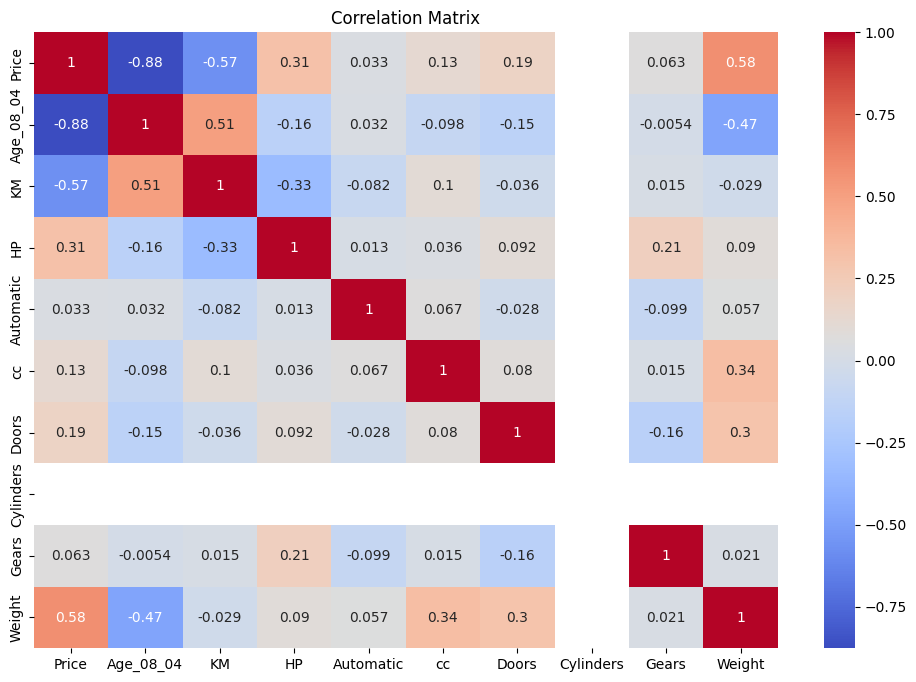

In [11]:
# Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

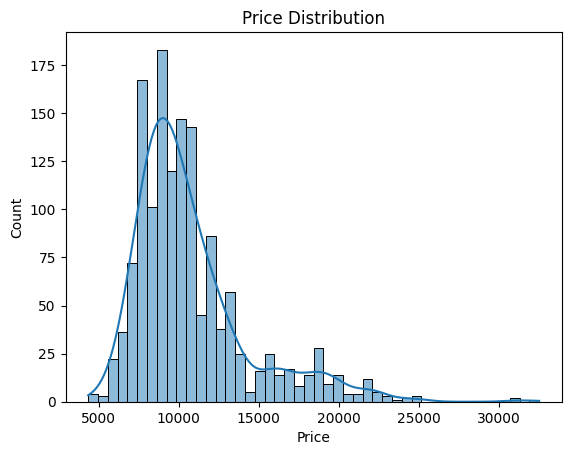

In [12]:
# Distribution of Target Variable
sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.show()

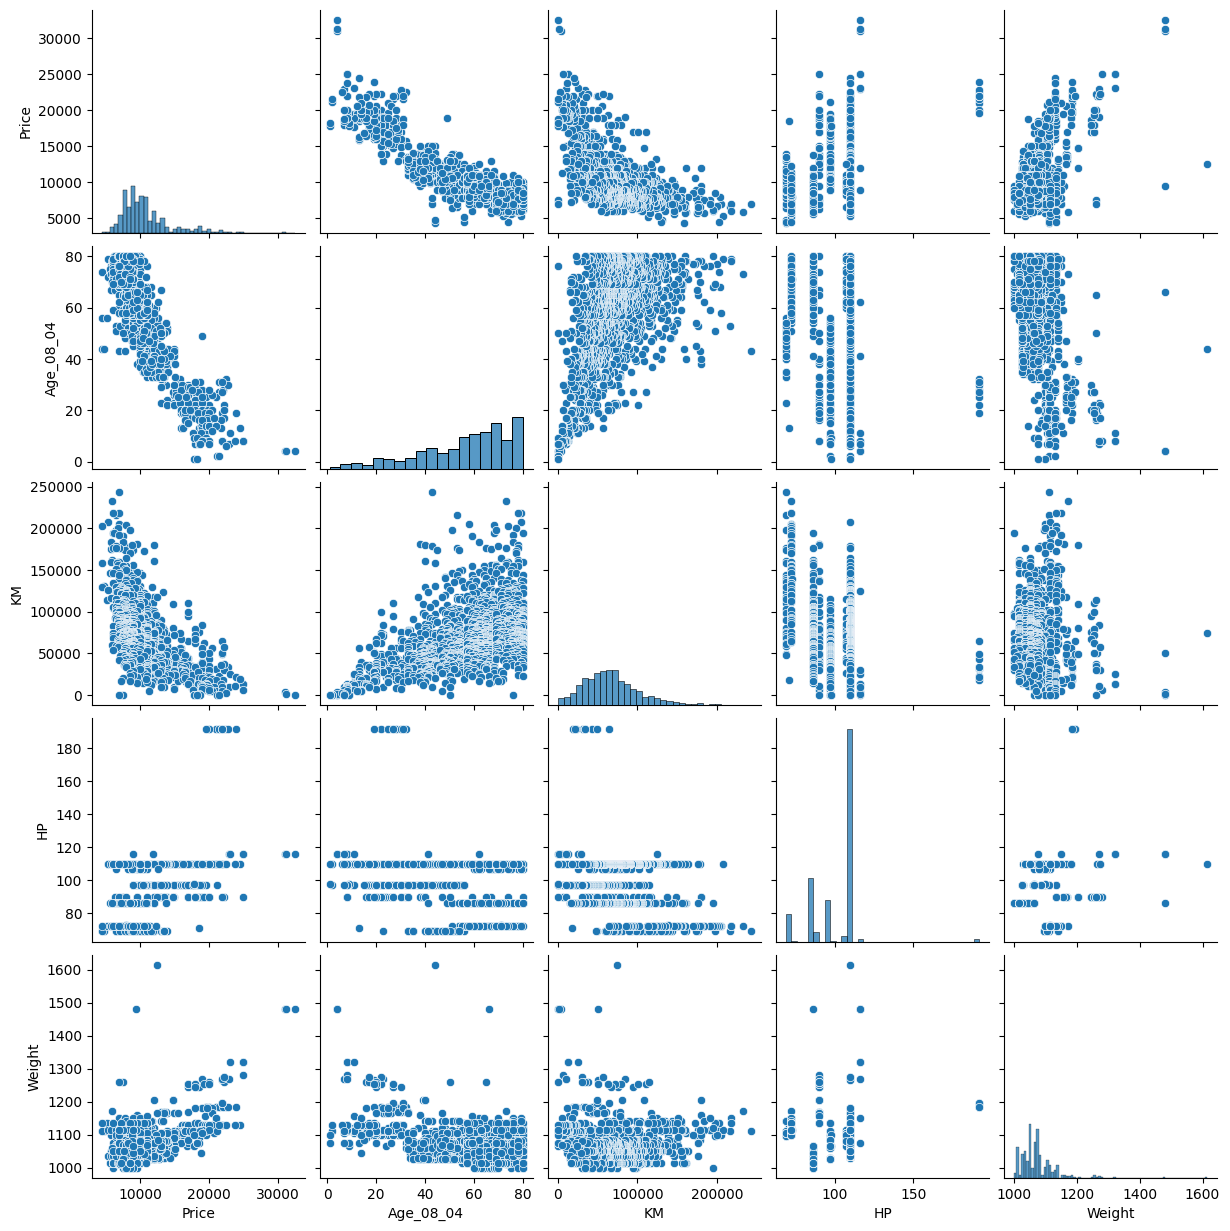

In [14]:
# Scatterplots with Target
sns.pairplot(df[['Price','Age_08_04','KM','HP','Weight']])
plt.show()

In [16]:
# Data Preprocessing
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [17]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [20]:
# Build Multiple Linear Regression Models
model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

In [21]:
print("R2 Score:", r2_score(y_test, y_pred1))
print("MAE:", mean_absolute_error(y_test, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))

R2 Score: 0.834888804061108
MAE: 990.8872739193968
RMSE: 1484.2654153296521


In [23]:
# Remove Highly Correlated Variables
X2 = df.drop(["Price","cc"], axis=1)  # Example removal
X2 = pd.get_dummies(X2, drop_first=True)
X2_scaled = scaler.fit_transform(X2)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("Model 2 R2:", r2_score(y_test2, y_pred2))

Model 2 R2: 0.8348264251698347


In [25]:
# Selected Important Features Only
important_features = ['Age_08_04','KM','HP','Weight']
X3 = df[important_features]

X3_scaled = scaler.fit_transform(X3)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3_scaled, y, test_size=0.2, random_state=42
)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

print("Model 3 R2:", r2_score(y_test3, y_pred3))

Model 3 R2: 0.8506068681500834


In [26]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, ridge_pred))

Ridge R2: 0.8350658145414687


In [27]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, lasso_pred))

Lasso R2: 0.8349119754675463


In [28]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model1.coef_
})

coeff_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
8,Weight,1.362139e+03
10,Fuel_Type_Petrol,4.451027e+02
2,HP,2.102533e+02
7,Gears,1.039463e+02
3,Automatic,3.413608e+01
6,Cylinders,2.842171e-13
4,cc,-1.288507e+01
9,Fuel_Type_Diesel,-2.127088e+01
5,Doors,-5.743684e+01
1,KM,-6.085706e+02


# Interview Questions:

**1.What is Normalization & Standardization and how is it helpful?**

Normalization and standardization are essential data preprocessing techniques that scale numerical features to a common range or distribution. Normalization (Min-Max Scaling) typically rescales data between 0 and 1. Standardization (Z-score normalization) transforms data to have a mean of 0 and a standard deviation of 1. Both are helpful for removing feature magnitude biases, accelerating gradient descent, and improving model performance.

**2.What techniques can be used to address multicollinearity in multiple linear regression?**

Multicollinearity in multiple linear regression can be addressed by removing highly correlated predictors, combining them into a single feature, or using specialized regression techniques. Key methods include checking Variance Inflation Factor (VIF) scores, using Principal Component Analysis (PCA) to reduce dimensions, applying regularization (Ridge/LASSO regression), or increasing the sample size.